# Four engines, one notebook — with real data

**Python · R · Stata · EViews**, on a single Python kernel.

This notebook works through a small applied exercise on **real US quarterly macroeconomic data, 1959Q1–2009Q3**, using each program for what it is genuinely best at:

| Step | Engine | Why that one |
|---|---|---|
| Load and transform the data | **Python** | pandas is the best tool for this |
| Describe and plot | **R** | `ggplot2`, and R's diagnostic vocabulary |
| Regression with HAC standard errors | **Stata** | `newey` is the reference implementation |
| Unit roots, cointegration, forecast | **EViews** | this is what EViews is for |
| Compare all four | **EconEnv** | same specification, four engines, one table |

The dataset moves between the programs **once**, in memory. No CSV is written at any point.

> **Requirements.** Python and the `econenv` package are enough to open this notebook. Each engine section additionally needs that program installed and licensed. Cells for an engine you do not have will fail with a clear message; the rest still run. See the *Installation Guide* PDF in `docs/` for setting each one up from zero.
---

**Developed by Dr Merwan Roudane**  
GitHub: <https://github.com/merwanroudane>  
Package: <https://pypi.org/project/econenv/>  
Repository: <https://github.com/merwanroudane/econenv>


## Installation

EconEnv is on PyPI. If it is not already in the Python that runs this
notebook:

```bash
pip install econenv
```

Or, from inside a notebook cell, which installs into **the kernel actually
running** rather than whichever Python happens to be first on your PATH:

```python
%pip install econenv
```

Optional extras, only if you need them:

```bash
pip install "econenv[eviews]"   # comtypes, for EViews on Windows
pip install "econenv[arrow]"    # faster transfer to R
pip install "econenv[all]"
```

The core install pulls in only pandas, numpy, IPython and statsmodels.
Nothing commercial is downloaded or bundled: R, Stata and EViews must be
installed and licensed by you. The *Installation and User Guide* PDF in
`docs/guide/` walks through all of them from zero.


In [1]:
# Uncomment if econenv is not installed in this kernel:
# %pip install econenv

## 0. Load the extension and check what is available

In [2]:
%load_ext econenv

EconEnv 0.1.6 loaded — one notebook, multiple econometric engines.
  %econ                  econenv
  %Rec / %%Rec           econenv
  %R / %%R               econenv (rpy2 not installed)
  %eviews / %%eviews     econenv
  %stata / %%stata       pystata (official)
  %econ status · %econ doctor · %econ help


In [3]:
%econ status

EconEnv 0.1.6


,state,version,edition,backend,location
engine,,,,,
Python,configured,3.11.0,,cpython,C:\Users\HP\AppData\Local\Programs\Python\Pyth...
EViews,configured,13,,comtypes,C:\Program Files\EViews 13
R,configured,4.5.2,,subprocess,C:\Program Files\R\R-4.5.2
Stata,running,19.5,mp,pystata,C:\Program Files\StataNow19


`%econ doctor` checks every layer and tells you how to fix whatever is missing. Run it if an engine below does not start.

In [4]:
%econ doctor

PASS,Python,3.11.0 at C:\Users\HP\AppData\Local\Programs\Python\Python311\python.exe
PASS,Operating system,Windows-10-10.0.26200-SP0
PASS,Architecture,AMD64
PASS,IPython,9.9.0
PASS,pandas,2.3.3
PASS,numpy,2.2.6
PASS,jupyterlab,4.5.6
PASS,pyarrow,23.0.1
PASS,Temporary directory,C:\Users\HP\AppData\Local\Temp
SKIP,Config file,none (would be C:\Users\HP\.econenv\config.toml)
PASS,R installation,C:\Program Files\R\R-4.5.2 (R 4.5.2)


## 1. Python — the data

`statsmodels` ships the US macro dataset used in Greene and in many textbooks, so this notebook needs no download and no private file.

We build a proper quarterly `DatetimeIndex`, because that is what lets EViews create a *dated* workfile page — without it, EViews treats the observations as unordered and the time-series tests below are meaningless.

In [5]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import econenv

raw = sm.datasets.macrodata.load_pandas().data

idx = pd.PeriodIndex(
    year=raw.year.astype(int), quarter=raw.quarter.astype(int), freq='Q'
).to_timestamp()

macro = pd.DataFrame(
    {
        'lrgdp': np.log(raw.realgdp.values),      # log real GDP
        'lrcons': np.log(raw.realcons.values),    # log real consumption
        'lrinv': np.log(raw.realinv.values),      # log real investment
        'unemp': raw.unemp.values,                # unemployment rate
        'infl': raw.infl.values,                  # inflation
        'tbill': raw.tbilrate.values,             # 3-month T-bill
        'realint': raw.realint.values,            # real interest rate
    },
    index=idx,
)
macro.index.name = 'date'
span = lambda t: str(t.year) + 'Q' + str(t.quarter)
print(len(macro), 'quarters,', span(macro.index[0]), 'to', span(macro.index[-1]))
macro.head()

203 quarters, 1959Q1 to 2009Q3


C:\Users\HP\AppData\Local\Temp\ipykernel_32228\680992750.py:8: FutureWarning: Constructing PeriodIndex from fields is deprecated. Use PeriodIndex.from_fields instead.
  idx = pd.PeriodIndex(


,lrgdp,lrcons,lrinv,unemp,infl,tbill,realint
date,,,,,,,
1959-01-01,7.904833,7.442727,5.659127,5.8,0.00,2.82,0.00
1959-04-01,7.929775,7.458013,5.739339,5.1,2.34,3.08,0.74
1959-07-01,7.928582,7.468399,5.667208,5.3,2.74,3.82,1.09
1959-10-01,7.932076,7.469483,5.701634,5.6,0.27,4.33,4.06
1960-01-01,7.954267,7.479017,5.804297,5.2,2.31,3.50,1.19


In [6]:
macro.describe().round(3)

,lrgdp,lrcons,lrinv,unemp,infl,tbill,realint
count,203.000,203.000,203.000,203.000,203.000,203.000,203.000
mean,8.781,8.362,6.750,5.885,3.961,5.312,1.337
std,0.466,0.501,0.596,1.459,3.253,2.803,2.669
min,7.905,7.443,5.560,3.400,-8.790,0.120,-6.790
25%,8.398,7.963,6.252,4.900,2.270,3.515,-0.085
50%,8.789,8.366,6.798,5.700,3.240,5.010,1.340
75%,9.173,8.764,7.270,6.800,4.975,6.665,2.630
max,9.504,9.145,7.725,10.700,14.620,15.330,10.950


### The question

A textbook consumption function:

$$\log C_t = \beta_0 + \beta_1 \log Y_t + \beta_2 r_t + \varepsilon_t$$

with $C$ real consumption, $Y$ real GDP and $r$ the real interest rate. $\beta_1$ is the long-run elasticity of consumption with respect to income, and should be close to 1.

Both series are strongly trending, so the interesting econometric questions — are they non-stationary, are they cointegrated, are the standard errors trustworthy — are exactly the ones each program answers differently.

## 2. R — describe and plot

`-i macro` sends the DataFrame into R. It arrives as a real `data.frame`, with the dates preserved.

In [7]:
%%R -i macro
cat('R received', nrow(macro), 'rows and', ncol(macro), 'columns\n')
str(macro[, 1:4])

R received 203 rows and 8 columns
'data.frame':	203 obs. of  4 variables:
 $ date  : POSIXct, format: "1959-01-01" "1959-04-01" "1959-07-01" ...
 $ lrgdp : num  7.9 7.93 7.93 7.93 7.95 ...
 $ lrcons: num  7.44 7.46 7.47 7.47 7.48 ...
 $ lrinv : num  5.66 5.74 5.67 5.7 5.8 ...


In [8]:
%%R
fit_r <- lm(lrcons ~ lrgdp + realint, data = macro)
summary(fit_r)


Call:
lm(formula = lrcons ~ lrgdp + realint, data = macro)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.030434 -0.011066 -0.000498  0.009559  0.038223 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) -1.0735725  0.0189306 -56.711  < 2e-16 ***
lrgdp        1.0746806  0.0021514 499.527  < 2e-16 ***
realint     -0.0010893  0.0003754  -2.902  0.00412 ** 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.01424 on 200 degrees of freedom
Multiple R-squared:  0.9992,	Adjusted R-squared:  0.9992 
F-statistic: 1.248e+05 on 2 and 200 DF,  p-value: < 2.2e-16


R's own diagnostic plots — the four-panel view every R user knows. These render straight into the notebook.

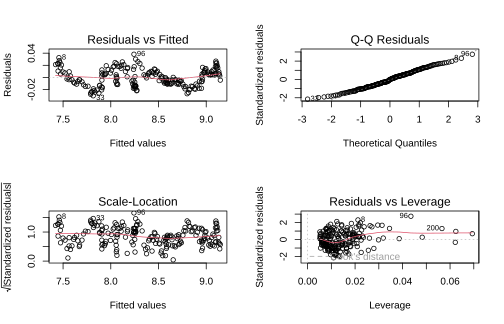

In [9]:
%%R
par(mfrow = c(2, 2))
plot(fit_r)

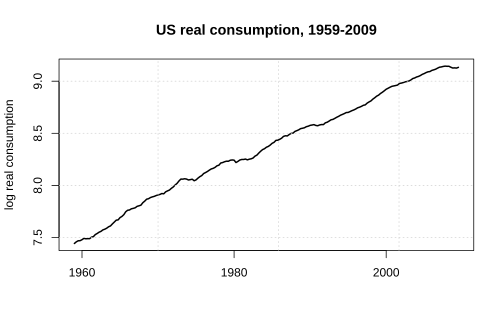

In [10]:
%%R
plot(macro$date, macro$lrcons, type = 'l', lwd = 2,
     xlab = '', ylab = 'log real consumption',
     main = 'US real consumption, 1959-2009')
grid()

## 3. Stata — standard errors that survive serial correlation

The residuals above are strongly autocorrelated, so ordinary standard errors are too small. `newey` is Stata's reference implementation of Newey–West HAC standard errors.

`%%stata` is **StataCorp's own magic**, loaded rather than reimplemented, so it takes Stata's options and not EconEnv's. Data moves with `%econ`.

In [11]:
%econ push stata macro

macro -> stata:macro


C:\Users\HP\Documents\econenv\src\econenv\engines\stata_engine.py:234: UserWarning: EconEnv push -> stata: [warning] date: datetime converted to Stata %tc (ms since 1960-01-01); apply `format ... %tc` in Stata to display it as a date
  push_frame(self, name, df, **kwargs)


In [12]:
%%stata
describe
summarize lrcons lrgdp realint


. describe

Contains data
 Observations:           203                  
    Variables:             8                  
-------------------------------------------------------------------------------
Variable      Storage   Display    Value
    name         type    format    label      Variable label
-------------------------------------------------------------------------------
date            double  %10.0g                
lrgdp           double  %10.0g                
lrcons          double  %10.0g                
lrinv           double  %10.0g                
unemp           double  %10.0g                
infl            double  %10.0g                
tbill           double  %10.0g                
realint         double  %10.0g                
-------------------------------------------------------------------------------
Sorted by: 
     Note: Dataset has changed since last saved.

. summarize lrcons lrgdp realint

    Variable |        Obs        Mean    Std. dev.       Min     

In [13]:
%%stata
regress lrcons lrgdp realint


      Source |       SS           df       MS      Number of obs   =       203
-------------+----------------------------------   F(2, 200)       >  99999.00
       Model |  50.5887154         2  25.2943577   Prob > F        =    0.0000
    Residual |  .040534139       200  .000202671   R-squared       =    0.9992
-------------+----------------------------------   Adj R-squared   =    0.9992
       Total |  50.6292496       202  .250639849   Root MSE        =    .01424



------------------------------------------------------------------------------


      lrcons | Coefficient  Std. err.      t    P>|t|     [95% conf. interval]


-------------+----------------------------------------------------------------


       lrgdp |

   1.074681   .0021514   499.53   0.000     1.070438    1.078923
     realint |  -.0010893   .0003754    -2.90   0.004    -.0018295   -.0003492
       _cons |  -1.073573   .0189306   -56.71   0.000    -1.110902   -1.036243


------------------------------------------------------------------------------


Now the same regression with HAC standard errors at four lags:

In [14]:
%%stata
tsset, clear
gen t = _n
tsset t
newey lrcons lrgdp realint, lag(4)


. tsset, clear

. gen t = _n

. tsset t

Time variable: t, 1 to 203
        Delta: 1 unit

. newey lrcons lrgdp realint, lag(4)



Regression with Newey–West standard errors      Number of obs     =        203
Maximum lag = 4                                 F(  2,       200) =   27912.43
                                                Prob > F          =     0.0000

------------------------------------------------------------------------------
             |             Newey–West
      lrcons | Coefficient  std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
       lrgdp |   1.074681   .0045675   235.29   0.000     1.065674    1.083687
     realint |  -.0010893   .0006084    -1.79   0.075    -.0022891    .0001105
       _cons |  -1.073573   .0406762   -26.39   0.000    -1.153782   -.9933633
------------------------------------------------------------------------------

. 


Compare the standard errors: the coefficient is unchanged, but the uncertainty around it is considerably larger once serial correlation is acknowledged. That is the whole reason to go to Stata for this step.

## 4. EViews — unit roots, cointegration, forecasting

`-i macro` creates a **dated quarterly workfile** from the DataFrame's index, which is what makes the time-series machinery below valid.

The DataFrame becomes a page of **series**, one per column — there is no object called `macro` in EViews, so refer to the series by name.

If you have only ever used EViews by clicking, run `%econ eviews` to look commands up without leaving the notebook.

In [15]:
%%eviews -i macro
lrcons.stats

Date: 09/04/26   Time: 13:51
Sample: 1959Q1 2009Q3

                              LRCONS

Mean                          8.361722
Median                        8.366347
Maximum                       9.144585
Minimum                       7.442727
Std. Dev.                     0.500639
Skewness                      -0.107083
Kurtosis                      1.913902

Jarque-Bera                   10.36549
Probability                   0.005613

Sum                           1697.430
Sum Sq. Dev.                  50.62925

Observations                  203


### 4.1 Are the series stationary?

GUI path: *Series → View → Unit Root Test → ADF*.

In [16]:
%%eviews
lrgdp.uroot(adf)

Null Hypothesis: LRGDP has a unit root
Exogenous: Constant
Lag Length: 1 (Automatic - based on SIC, maxlag=14)

                                                                                         t-Statistic  Prob.*

Augmented Dickey-Fuller test statistic                                                   -1.820451    0.3698
Test critical values:                                1% level                            -3.462901
                                                     5% level                            -2.875752
                                                     10% level                           -2.574423

*MacKinnon (1996) one-sided p-values.


Augmented Dickey-Fuller Test Equation
Dependent Variable: D(LRGDP)
Method: Least Squares
Date: 09/04/26   Time: 13:51
Sample (adjusted): 1959Q3 2009Q3
Included observations: 201 after adjustments

Variable                                             Coefficient  Std. Error             t-Statistic  Prob.

LRGDP(-1)                

In [17]:
%%eviews
lrcons.uroot(adf)

Null Hypothesis: LRCONS has a unit root
Exogenous: Constant
Lag Length: 3 (Automatic - based on SIC, maxlag=14)

                                                                                         t-Statistic  Prob.*

Augmented Dickey-Fuller test statistic                                                   -1.644935    0.4577
Test critical values:                                1% level                            -3.463235
                                                     5% level                            -2.875898
                                                     10% level                           -2.574501

*MacKinnon (1996) one-sided p-values.


Augmented Dickey-Fuller Test Equation
Dependent Variable: D(LRCONS)
Method: Least Squares
Date: 09/04/26   Time: 13:51
Sample (adjusted): 1960Q1 2009Q3
Included observations: 199 after adjustments

Variable                                             Coefficient  Std. Error             t-Statistic  Prob.

LRCONS(-1)             

Both fail to reject a unit root in levels. The standard next step is to test the first differences:

In [18]:
%%eviews
lrgdp.uroot(adf, dif=1)

Null Hypothesis: D(LRGDP) has a unit root
Exogenous: Constant
Lag Length: 1 (Automatic - based on SIC, maxlag=14)

                                                                                         t-Statistic  Prob.*

Augmented Dickey-Fuller test statistic                                                   -6.972871    0.0000
Test critical values:                                1% level                            -3.463067
                                                     5% level                            -2.875825
                                                     10% level                           -2.574462

*MacKinnon (1996) one-sided p-values.


Augmented Dickey-Fuller Test Equation
Dependent Variable: D(LRGDP,2)
Method: Least Squares
Date: 09/04/26   Time: 13:51
Sample (adjusted): 1959Q4 2009Q3
Included observations: 200 after adjustments

Variable                                             Coefficient  Std. Error             t-Statistic  Prob.

D(LRGDP(-1))        

### 4.2 Are they cointegrated?

If both series are I(1) but a linear combination is stationary, a regression in levels is meaningful rather than spurious.

GUI path: *Group → View → Cointegration Test → Johansen*.

In [19]:
%%eviews
group gci lrcons lrgdp
gci.coint(e)

                   Johansen Cointegration Test
Date: 09/04/26   Time: 13:51                                               
Sample: 1959Q1 2009Q3                                                      
Included observations: 203                                                 
Lags interval (in first differences): 1 to 4                               
Endogenous variables: LRCONS LRGDP                                         
Deterministic assumptions: Case 5 (Johansen-Hendry-Juselius): Both the     
        cointegrating relationship and short-run dynamics include a constan
        trend.                                                             

Unrestricted Cointegration Rank Test (Trace)                               
Hypothesized                  Trace        0.05        Prob.**             
No. of CE(s)  Eigenvalue    Statistic  Critical ValuCritical Value         
    None        0.048363     16.51271     18.39771      0.0900             
 At most 1 *    0.033260     6.697437   

### 4.3 The equation, and what EViews shows after estimating it

In [20]:
%%eviews
equation eq_ev.ls lrcons c lrgdp realint
eq_ev.output

Dependent Variable: LRCONS
Method: Least Squares
Date: 09/04/26   Time: 13:51
Sample: 1959Q1 2009Q3
Included observations: 203

Variable                      Coefficient  Std. Error             t-Statistic  Prob.

C                             -1.073573    0.018931               -56.71091    0.0000
LRGDP                         1.074681     0.002151               499.5275     0.0000
REALINT                       -0.001089    0.000375               -2.902182    0.0041

R-squared                     0.999199     Mean dependent var                  8.361722
Adjusted R-squared            0.999191     S.D. dependent var                  0.500639
S.E. of regression            0.014236     Akaike info criterion               -5.651383
Sum squared resid             0.040534     Schwarz criterion                   -5.602419
Log likelihood                576.6154     Hannan-Quinn criter.                -5.631574
F-statistic                   124805.2     Durbin-Watson stat                  0.278

Actual, fitted and residual — the first thing to look at:

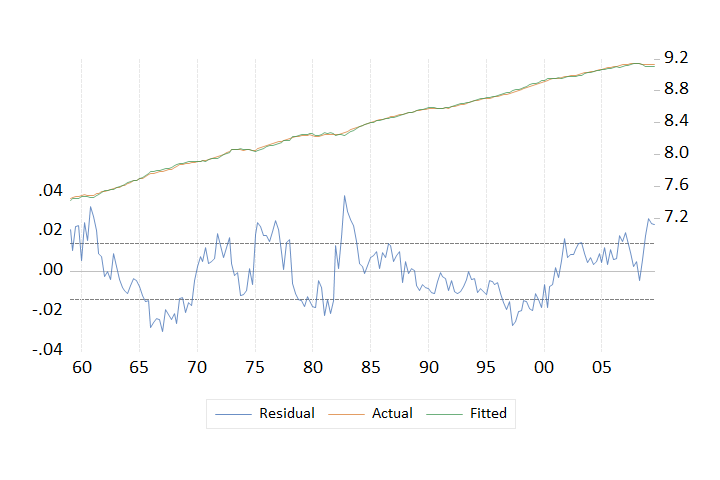

In [21]:
%%eviews
eq_ev.resids

Parameter stability — the CUSUM test (`rls(q)`) and CUSUM of squares (`rls(v)`):

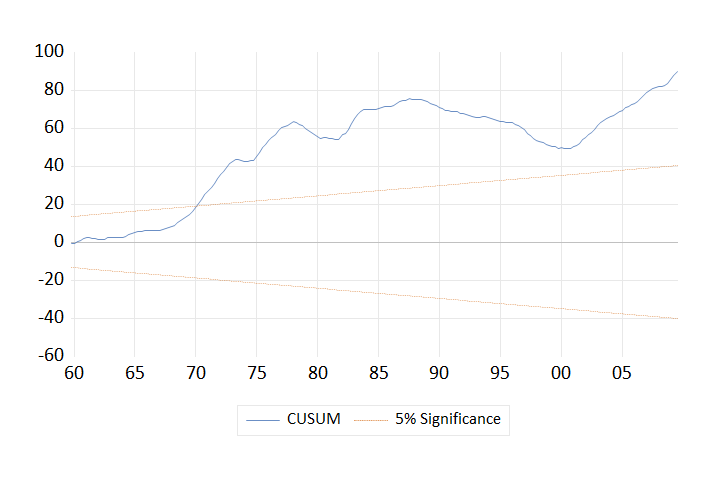

In [22]:
%%eviews
eq_ev.rls(q)

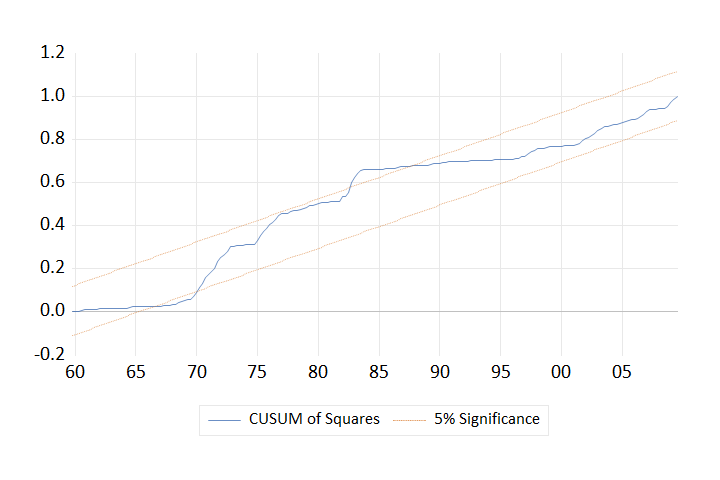

In [23]:
%%eviews
eq_ev.rls(v)

### 4.4 A forecast

Estimate on a shorter sample, then forecast over the rest — the standard out-of-sample exercise.

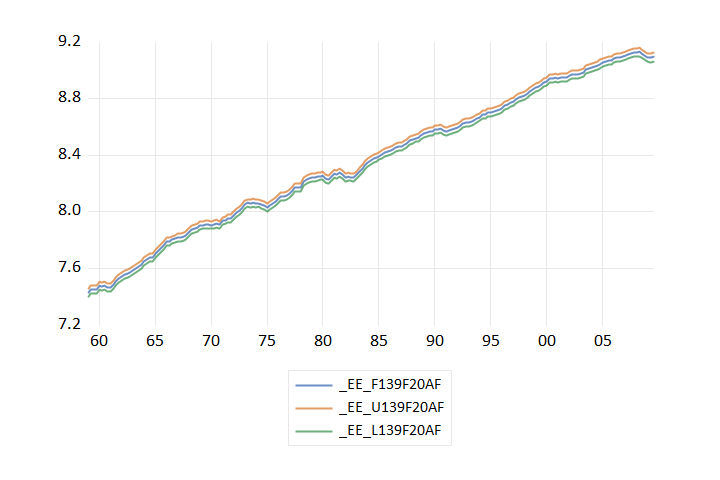

In [24]:
%%eviews
smpl 1959Q1 1999Q4
equation eq_fc.ls lrcons c lrgdp realint
smpl 1959Q1 2009Q3
eq_fc.forecast(g) lrcons_f

EViews draws its forecast graph in a window that belongs to no object and cannot be exported, so EconEnv rebuilds the same picture — forecast ± 2 standard errors — and labels it so you know it was reconstructed.

Time-series plots, three equivalent ways to write the same thing:

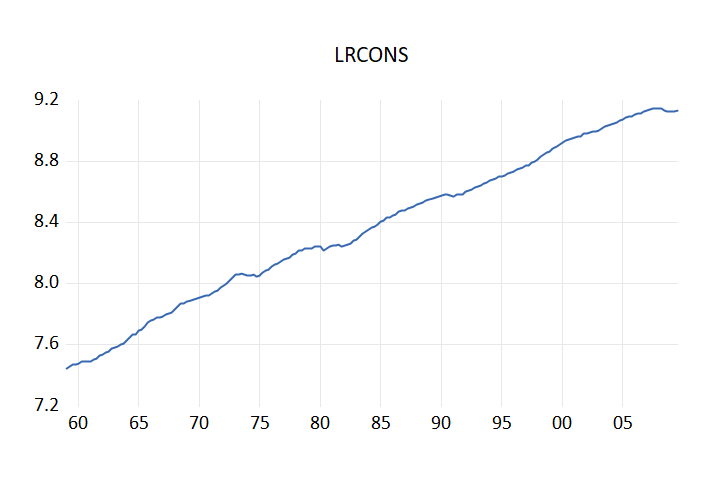

In [25]:
%%eviews
smpl @all
line lrcons

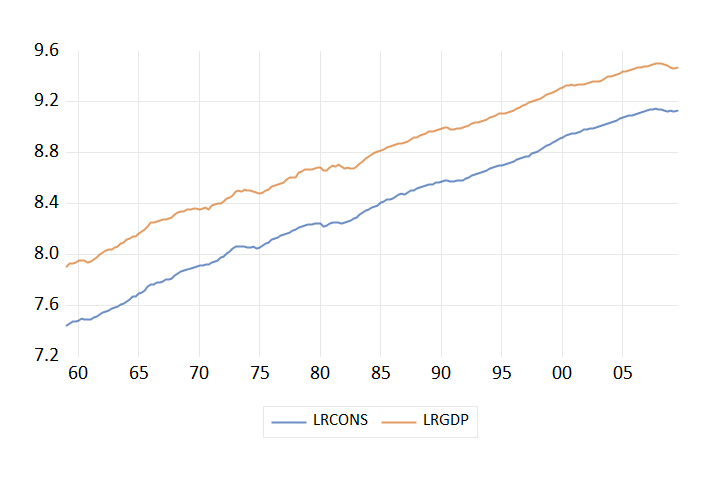

In [26]:
%%eviews
group gplot lrcons lrgdp
gplot.line

## 5. Bring results back to Python

Everything above stays available. Pull the forecast series back and work with it in pandas.

In [27]:
back = econenv.pull('eviews')
print(type(back).__name__, back.shape)
back.tail()

DataFrame (203, 8)


,INFL,LRCONS,LRCONS_F,LRGDP,LRINV,REALINT,TBILL,UNEMP
2008-07-01,-3.16,9.134291,9.118511,9.497367,7.596238,4.33,1.17,6.0
2008-10-01,-8.79,9.126448,9.102161,9.483562,7.527073,8.91,0.12,6.9
2009-01-01,0.94,9.127958,9.088011,9.466950,7.351475,-0.71,0.22,8.1
2009-04-01,3.37,9.125762,9.086948,9.465099,7.283914,-3.19,0.18,9.2
2009-07-01,3.56,9.133027,9.094336,9.471961,7.304111,-3.44,0.12,9.6


## 6. The same model in all four engines

This is the part that is hard to do any other way: one specification, four programs, one table — and an honest account of where they differ.

In [28]:
cmp = econenv.compare_ols(macro, 'lrcons ~ lrgdp + realint')
cmp

C:\Users\HP\Documents\econenv\src\econenv\engines\stata_engine.py:356: UserWarning: EconEnv push -> stata: [warning] date: datetime converted to Stata %tc (ms since 1960-01-01); apply `format ... %tc` in Stata to display it as a date
  push_frame(self, "__econenv_ols", data.loc[:, columns], clear=True)


OLS: lrcons ~ lrgdp + realint

Coefficients
                python         eviews              r          stata
term                                                               
_cons       -1.0735725     -1.0735725     -1.0735725     -1.0735725
lrgdp        1.0746806      1.0746806      1.0746806      1.0746806
realint  -0.0010893364  -0.0010893364  -0.0010893364  -0.0010893364

Summary statistics
       version model  nobs        r2    r2_adj      loglik          aic          bic      rmse       vcov
engine                                                                                                   
python  3.11.0   OLS   203  0.999199  0.999191  576.615373 -1147.230747 -1137.291129  0.014236  nonrobust
eviews      13   OLS   203  0.999199  0.999191  576.615373    -5.651383    -5.602419  0.014236        ols
r        4.5.2   OLS   203  0.999199  0.999191  576.615373 -1145.230747 -1131.977923  0.014236  nonrobust
stata     19.5   OLS   203  0.999199  0.999191  576.615373 -1147.230747 -1137.291129  0.014236  nonrobust

Agreement: all engines agree within tolerance
         max_abs_diff  max_rel_diff  within_tolerance
term                                                 
_cons    3.013145e-13  2.806653e-13              True
lrgdp    3.619327e-14  3.367817e-14              True
realint  4.724953e-16  4.337460e-13              True

Notes:
  - aic: AIC normalisation differs: statsmodels -2ll+2k; R counts sigma^2 as a parameter (k+1); EViews divides by n; Stata needs `estat ic`.
  - bic: BIC follows the same normalisation differences as AIC.
  - python: statsmodels AIC/BIC use -2*llf + 2k / -2*llf + k*ln(n); Stata and EViews normalise differently — see docs/comparison.md.
  - eviews: EViews lists the constant first; term order is normalised here.
  - eviews: EViews AIC/BIC are divided by the number of observations, unlike statsmodels — see docs/comparison.md.
  - r: R's AIC/BIC count the error variance as a parameter (k+1), so they sit one parameter above statsmodels' — see docs/comparison.md.
  - stata: AIC/BIC come from `estat ic`; Stata's normalisation is -2ll + 2k with k = e(rank) + 1, which differs from statsmodels and from EViews — see docs/comparison.md.

In [29]:
cmp.coefficients()

,python,eviews,r,stata
term,,,,
_cons,-1.073573,-1.073573,-1.073573,-1.073573
lrgdp,1.074681,1.074681,1.074681,1.074681
realint,-0.001089,-0.001089,-0.001089,-0.001089


The coefficients agree to machine precision. The information criteria do **not**, and EconEnv says why rather than silently picking one normalisation:

- `statsmodels`: $-2\ell + 2k$
- R: counts $\sigma^2$ as a parameter, so $k+1$
- EViews: divides by $n$
- Stata: needs `estat ic`, and uses $k = e(\text{rank}) + 1$

None of them is wrong. They are answering slightly different questions, and a comparison that hid that would be worse than useless.

## 7. Reproducibility

Record exactly what produced these numbers — every engine, every version.

In [30]:
snap = econenv.snapshot()
snap

{'econenv_version': '0.1.6',
 'timestamp': '2026-09-04T11:51:21.747374+00:00',
 'host': {'platform': 'Windows-10-10.0.26200-SP0',
  'system': 'Windows',
  'release': '10',
  'machine': 'AMD64',
  'processor': 'Intel64 Family 6 Model 154 Stepping 4, GenuineIntel',
  'python_version': '3.11.0',
  'python_implementation': 'CPython',
  'python_executable': 'C:\\Users\\HP\\AppData\\Local\\Programs\\Python\\Python311\\python.exe'},
 'engines': {'python': {'name': 'python',
   'display_name': 'Python',
   'state': 'running',
   'version': '3.11.0',
   'edition': None,
   'home': 'C:\\Users\\HP\\AppData\\Local\\Programs\\Python\\Python311',
   'executable': 'C:\\Users\\HP\\AppData\\Local\\Programs\\Python\\Python311\\python.exe',
   'backend': 'cpython',
   'platform_supported': True,
   'capabilities': ['execute',
    'persistent_session',
    'push_frame',
    'pull_frame',
    'push_scalar',
    'pull_scalar',
    'pull_matrix',
    'graphics',
    'ols',
    'restart'],
   'detail': {'pref

---

## What this notebook demonstrated

1. One dataset, built once in Python, used by three other programs with **no file written**.
2. Each program used for its own strength, in its own language, in one kernel.
3. Plots from R and EViews rendered inline alongside Python's.
4. The same model estimated in all four and compared, with the differences explained rather than hidden.
5. A reproducibility snapshot recording every version involved.

### Where to go next

- `%econ eviews` — look up EViews commands from a cell
- `%econ doctor` — diagnose any engine that will not start
- [`docs/`](../docs/) — engine notes, data exchange, troubleshooting
- The *Installation Guide* PDF — setting up all four programs from zero

*EconEnv — Dr Merwan Roudane — <https://github.com/merwanroudane/econenv>*